# Homework 4 - Sample Solutions

In [ ]:
# Installing EoN in your environment/kernel
%pip install EoN

In [1]:
# Required packages
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.barabasi_albert_graph(100, 2)

vax_fractions = np.linspace(0.01, 1, 101)
realizations = 10

no_vaccination = []

tau = 0.2 #Transmission rate (beta)
gamma = 0.1 #Recovery rate

for i, f in enumerate(vax_fractions):
    no_vac = []
    for j in range(realizations):
        vaxxed_nodes = [] #No one vaccinated

        # This function takes our Graph, beta, gamma, initial infected, and initial recovered as inputs
        # If you are vaccinated then you are considered initial recovered, the function automatically chooses a node to be infected
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, initial_infecteds=None, initial_recovereds=vaxxed_nodes)

        # Adding the final recovered population in my storage, analogue to how many were infected
        # If len(R) = 0, that means the infection never persisted so there were 0 infected
        no_vac.append(R[-1] if len(R) != 0 else 0)
    
    # Appending the mean of all realization in my storage
    no_vaccination.append(np.mean(no_vac))

(0.0, 100.0)

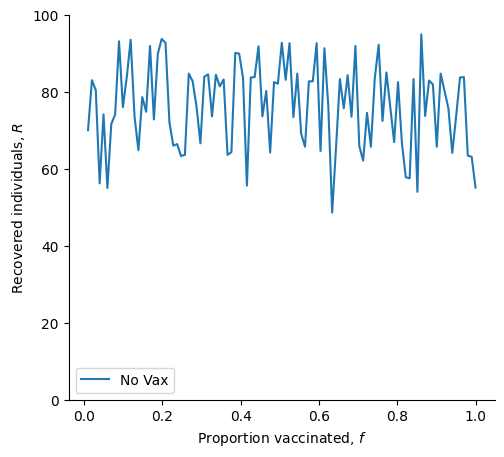

In [2]:
import seaborn as sns

plt.figure(figsize=(5.5,5))
plt.plot(vax_fractions, no_vaccination, label = "No Vax")
plt.legend()
sns.despine()
plt.xlabel(r"Proportion vaccinated, $f$")
plt.ylabel(r"Recovered individuals, $R$")
plt.ylim(0, 100)